In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

import pandas as pd

import requests
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from pathlib import Path
import shutil

import matplotlib.pyplot as plt


# Exploration
### Playing around with opensky REST API

In [5]:
TOKEN_URL = "https://auth.opensky-network.org/auth/realms/opensky-network/protocol/openid-connect/token"
CLIENT_ID = os.getenv("OPENSKY_CLIENT_ID")
CLIENT_SECRET = os.getenv("OPENSKY_CLIENT_SECRET")

# How many seconds before expiry to proactively refresh the token.
TOKEN_REFRESH_MARGIN = 30


class TokenManager:
    def __init__(self):
        self.token = None
        self.expires_at = None

    def get_token(self):
        """Return a valid access token, refreshing automatically if needed."""
        if self.token and self.expires_at and datetime.now() < self.expires_at:
            return self.token
        return self._refresh()

    def _refresh(self):
        """Fetch a new access token from the OpenSky authentication server."""
        r = requests.post(
            TOKEN_URL,
            data={
                "grant_type": "client_credentials",
                "client_id": CLIENT_ID,
                "client_secret": CLIENT_SECRET,
            },
        )
        r.raise_for_status()

        data = r.json()
        self.token = data["access_token"]
        expires_in = data.get("expires_in", 1800)
        self.expires_at = datetime.now() + timedelta(seconds=expires_in - TOKEN_REFRESH_MARGIN)
        return self.token

    def headers(self):
        """Return request headers with a valid Bearer token."""
        return {"Authorization": f"Bearer {self.get_token()}"}


# Create a single shared instance for your script.
tokens = TokenManager()

# Use it for any API call — the token is refreshed automatically.
response = requests.get(
    "https://opensky-network.org/api/states/all",
    headers=tokens.headers(),
)
print(response.json())

{'time': 1773146867, 'states': [['39de4f', 'TVF38RR ', 'France', 1773146866, 1773146866, 12.4835, 45.3233, 11582.4, False, 227.76, 279.23, 0, None, 11506.2, '5321', False, 0], ['c07d0b', 'CGVJE   ', 'Canada', 1773146646, 1773146649, -74.3916, 45.6382, 198.12, False, 24.45, 81.53, -2.28, None, 152.4, None, False, 0], ['4b1817', 'SWR3CT  ', 'Switzerland', 1773146556, 1773146556, -0.4589, 51.476, None, True, 5.92, 90, None, None, None, '3012', False, 0], ['4b1819', 'SWR5KV  ', 'Switzerland', 1773146867, 1773146867, -2.3725, 40.5778, 11597.64, False, 218.55, 24.03, 0, None, 11582.4, '4514', False, 0], ['801638', 'AXB1041 ', 'India', 1773146609, 1773146609, 77.1142, 28.567, None, True, 3.34, 250.31, None, None, None, None, False, 0], ['a2e5ec', 'SKW4296 ', 'United States', 1773146866, 1773146866, -93.1627, 44.7542, 1821.18, False, 136.16, 147.81, 0.65, None, 1760.22, '6007', False, 0], ['88044a', 'AIQ3926 ', 'Thailand', 1773146865, 1773146866, 100.6369, 13.9699, 297.18, False, 73.45, 208.9,

In [6]:
data = response.json()

columns = [
    "icao24","callsign","origin_country","time_position","last_contact",
    "longitude","latitude","baro_altitude","on_ground","velocity",
    "true_track","vertical_rate","sensors","geo_altitude",
    "squawk","spi","position_source"
]

df = pd.DataFrame(data["states"], columns=columns)

print(df.head())
print(df.shape)

   icao24  callsign origin_country  time_position  last_contact  longitude  \
0  39de4f  TVF38RR          France   1.773147e+09    1773146866    12.4835   
1  c07d0b  CGVJE            Canada   1.773147e+09    1773146649   -74.3916   
2  4b1817  SWR3CT      Switzerland   1.773147e+09    1773146556    -0.4589   
3  4b1819  SWR5KV      Switzerland   1.773147e+09    1773146867    -2.3725   
4  801638  AXB1041           India   1.773147e+09    1773146609    77.1142   

   latitude  baro_altitude  on_ground  velocity  true_track  vertical_rate  \
0   45.3233       11582.40      False    227.76      279.23           0.00   
1   45.6382         198.12      False     24.45       81.53          -2.28   
2   51.4760            NaN       True      5.92       90.00            NaN   
3   40.5778       11597.64      False    218.55       24.03           0.00   
4   28.5670            NaN       True      3.34      250.31            NaN   

  sensors  geo_altitude squawk    spi  position_source  
0    

In [7]:
tokens = TokenManager()

# Use it for any API call — the token is refreshed automatically.
response = requests.get(
    "https://opensky-network.org/api/flights/arrival?airport=LFBO",
    headers=tokens.headers(),
)
print(response.json())

{'timestamp': 1773146875134, 'status': 400, 'error': 'Bad Request', 'message': "Required int parameter 'begin' is not present", 'path': '/flights/arrival'}


In [8]:
from datetime import datetime, timezone

def get_arrivals(airport: str, start: datetime, end: datetime) -> dict:
    """
    Fetch arrivals at a specific airport between start and end times. 
    Be carefull max time range is 7 days.
    """
    url = "https://opensky-network.org/api/flights/arrival"
    params = {
        "airport": airport,
        "begin": int(start.timestamp()),
        "end": int(end.timestamp()),
    }
    response = requests.get(url, headers=tokens.headers(), params=params)
    response.raise_for_status()
    return response.json()

# Test — one day of arrivals at Toulouse
start = datetime(2025, 3, 1, tzinfo=timezone.utc)
end   = datetime(2025, 3, 2, tzinfo=timezone.utc)

data = get_arrivals("LFBO", start, end)
print(f"Got {len(data)} arrivals")
print(data[0])  

Got 78 arrivals
{'icao24': '4ca2d5', 'firstSeen': 1740864123, 'estDepartureAirport': 'LPPT', 'lastSeen': 1740869473, 'estArrivalAirport': 'LFBO', 'callsign': 'RYR63NR ', 'estDepartureAirportHorizDistance': 1266, 'estDepartureAirportVertDistance': 22, 'estArrivalAirportHorizDistance': 2842, 'estArrivalAirportVertDistance': 45, 'departureAirportCandidatesCount': 1, 'arrivalAirportCandidatesCount': 3}


In [9]:
def get_track(icao24: str, timestamp: int) -> dict:
    url = "https://opensky-network.org/api/tracks/all"
    params = {
        "icao24": icao24,
        "time": timestamp,
    }
    response = requests.get(url, headers=tokens.headers(), params=params)
    response.raise_for_status()
    return response.json()

#DOES NOT WORK too many requests
#flight = data[0]
#track = get_track(flight["icao24"], flight["firstSeen"])
#print(track.keys())
#print(f"Track points: {len(track['path'])}")
#print(track['path'][0])  # first position point

Because of the limitation of calls to the REST AI of opensky I decided to changed dataset

# Finding a new datasets
www.eurocontrol.int

In [10]:
def download_flight_list(year_month: str, save_dir: str):
    url = f"https://www.eurocontrol.int/performance/data/download/OPDI/v002/flight_list/flight_list_{year_month}.parquet"
    path = f"{save_dir}/flight_list_{year_month}.parquet"
    r = requests.get(url)
    r.raise_for_status()
    with open(path, "wb") as f:
        f.write(r.content)
    return pd.read_parquet(path)

#Create or clean output directories
folder = 'data'
if os.path.exists(folder):
    shutil.rmtree(folder)      
    os.makedirs(folder)       
Path(f"{folder}/raw").mkdir(parents=True, exist_ok=True)
Path(f"{folder}/processed").mkdir(parents=True, exist_ok=True)

      

year = "2024"
# Pull one year months by month
for ym in [f"{year}{i:02d}" for i in range(1, 13)]:
    df = download_flight_list(ym, "data/raw")
    lfbo = df[df["ades"] == "LFBO"]  # filter arrivals at Toulouse    
    lfbo.to_parquet(f"data/processed/lfbo_{ym}.parquet")
    print(f"{ym}: {len(lfbo)} arrivals at LFBO")

202401: 2639 arrivals at LFBO
202402: 2813 arrivals at LFBO
202403: 3096 arrivals at LFBO
202404: 3373 arrivals at LFBO
202405: 3300 arrivals at LFBO
202406: 3568 arrivals at LFBO
202407: 3176 arrivals at LFBO
202408: 2696 arrivals at LFBO
202409: 3586 arrivals at LFBO
202410: 3429 arrivals at LFBO
202411: 3021 arrivals at LFBO
202412: 3038 arrivals at LFBO


In [11]:
df = pd.read_parquet("data/processed/").reset_index(drop=True)

print(f"Total flights: {len(df)}")
print(f"Date range: {df['first_seen'].min()} → {df['first_seen'].max()}")

Total flights: 37735
Date range: 2024-01-01 03:46:40 → 2024-12-31 20:50:05


In [12]:
df.head()

,id,icao24,flt_id,dof,adep,ades,adep_p,ades_p,registration,model,typecode,icao_aircraft_class,icao_operator,first_seen,last_seen,version,unix_time
0,5121734936301840,4d226e,RYR6J,2024-01-01,EBCI,LFBO,,,9H-QCZ,None,B738,L2J,None,2024-01-01 19:50:10,2024-01-01 21:08:05,v2.0.0,1704138610
1,11013383691173806,394c13,AFR32XB,2024-01-12,LFPG,LFBO,,,F-GTAT,A321 212,A321,L2J,AFR,2024-01-12 11:43:15,2024-01-12 12:43:35,v2.0.0,1705059795
2,11531802292842984,3474ce,SWT5629,2024-01-13,LFPG,LFBO,,,EC-OBN,Boeing 737-83N(BCF),B738,None,NPT,2024-01-13 00:56:30,2024-01-13 01:55:55,v2.0.0,1705107390
3,13992860822844767,440625,EJU926D,2024-01-02,LFRN,LFBO,,,OE-LKM,None,A319,L2J,EJU,2024-01-02 19:57:30,2024-01-02 20:53:45,v2.0.0,1704225450
4,23704184912556119,4d226e,RYR6YW,2024-01-15,EPKK,LFBO,,,9H-QCZ,None,B738,L2J,None,2024-01-15 13:34:40,2024-01-15 16:23:55,v2.0.0,1705325680


# Data Visualisations

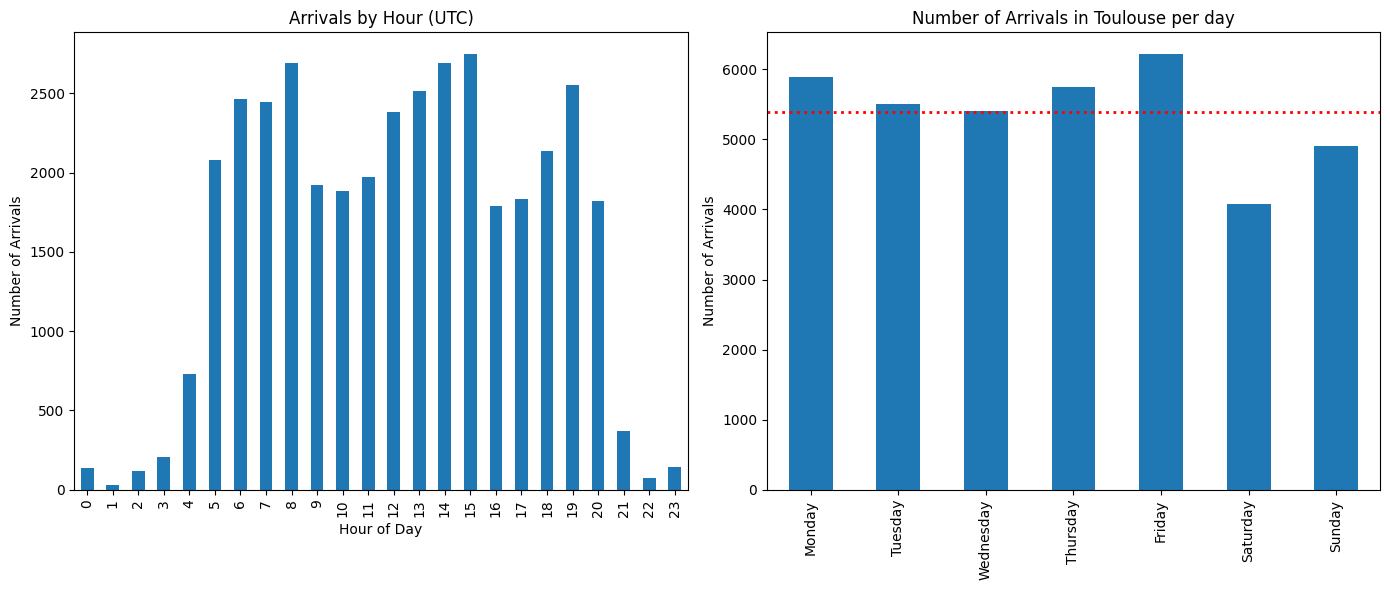

In [13]:
df["hour_of_day"] = df["first_seen"].dt.hour
df["day_of_week"] = df["first_seen"].dt.dayofweek 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Arrivals by Hour (UTC)", xlabel="Hour of Day", ylabel="Number of Arrivals")
df["day_of_week"].value_counts().sort_index().rename(index=dict(enumerate(days))).plot(kind="bar", ax=axes[1], title="Number of Arrivals in Toulouse per day", xlabel="", ylabel="Number of Arrivals")
axes[1].axhline(y=df["day_of_week"].value_counts().mean(), color='red', linestyle=':', linewidth=2, label=f'Avg: {df["day_of_week"].value_counts().mean():.1f}')

plt.tight_layout()
plt.show()

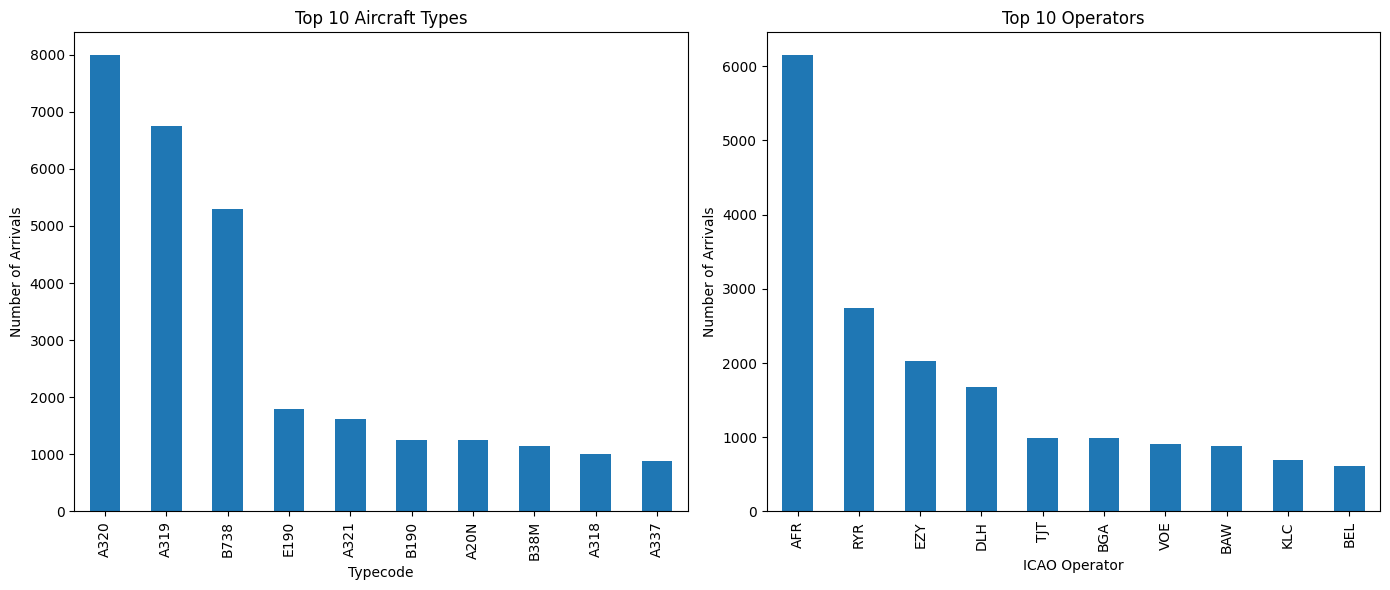

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

df["typecode"].value_counts().head(10).plot(kind="bar", ax=ax[0], title="Top 10 Aircraft Types",xlabel="Typecode", ylabel="Number of Arrivals")
df["icao_operator"].value_counts().head(10).plot(kind="bar", ax=ax[1], title="Top 10 Operators", xlabel="ICAO Operator", ylabel="Number of Arrivals")
plt.tight_layout()
plt.show()


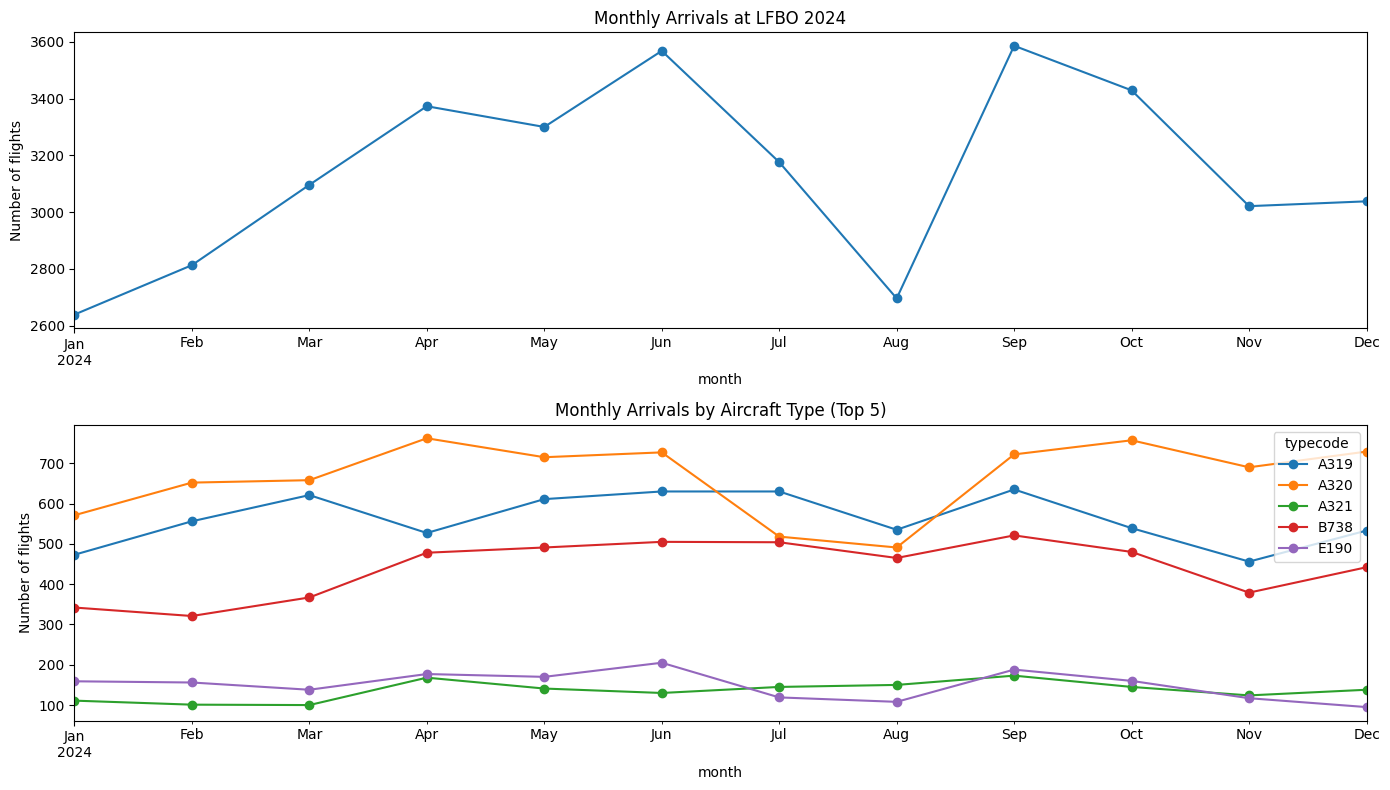

In [15]:
df["month"] = df["first_seen"].dt.to_period("M")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df.groupby("month").size().plot(ax=axes[0], marker="o", title=f"Monthly Arrivals at LFBO {year}")
axes[0].set_ylabel("Number of flights")

top_types = df["typecode"].value_counts().head(5).index
df[df["typecode"].isin(top_types)].groupby(["month", "typecode"]).size().unstack().plot(ax=axes[1], marker="o", title="Monthly Arrivals by Aircraft Type (Top 5)")
axes[1].set_ylabel("Number of flights")

plt.tight_layout()
plt.show()

# Anomaly Detection

## Threshold Selection — Tukey IQR vs Percentile

Tukey IQR upper bound (145 min) is too aggressive for aviation data.
LFBO serves medium-haul routes (North Africa, Middle East) with 
legitimate durations of 150-210 minutes. Tukey would incorrectly 
flag these as anomalies, generating excessive false positives.

p01/p99 thresholds (20 min / 216 min) better respect the actual 
operational envelope of the airport. Duration alone is a weak 
anomaly signal — it will be one feature among many in the model, 
not a standalone filter.

Tukey IQR is appropriate for symmetric distributions. 
Flight duration is right-skewed, making percentile-based 
thresholds more robust.

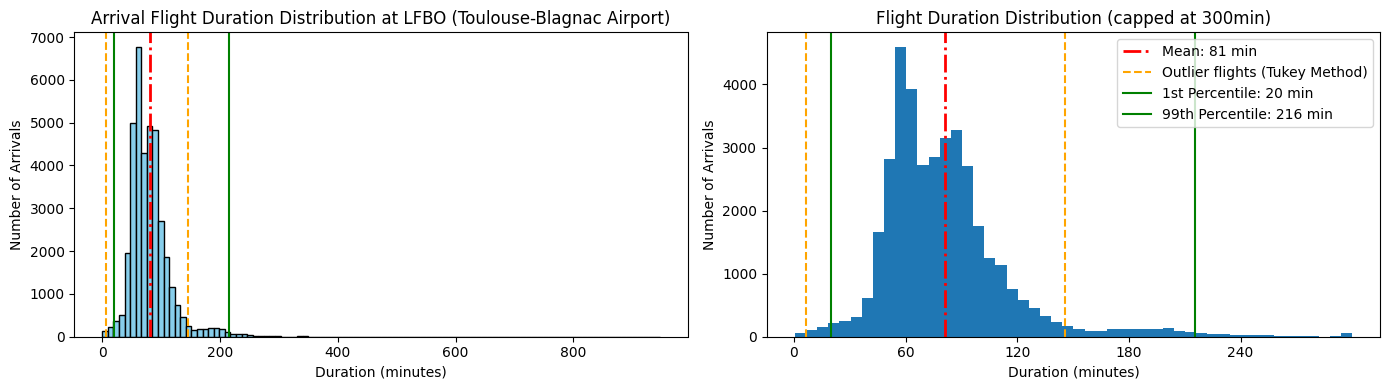

In [16]:
# Flight duration
df["duration_minutes"] = (df["last_seen"] - df["first_seen"]).dt.total_seconds() / 60
mean_val = df["duration_minutes"].mean()
p01 = df["duration_minutes"].quantile(0.01)
p99 = df["duration_minutes"].quantile(0.99)
Q1_val = df["duration_minutes"].quantile(0.25)
Q3_val = df["duration_minutes"].quantile(0.75)
IQR = Q3_val-Q1_val

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df["duration_minutes"], bins=100, color='skyblue', edgecolor='black')
ax[0].set_xlabel("Duration (minutes)")
ax[0].set_ylabel("Number of Arrivals")
ax[0].axvline(mean_val, color="red", linestyle="-.", label=f"Mean: {mean_val:.0f} min", linewidth=2)
ax[0].axvline(Q1_val-1.5*IQR, color="orange", linestyle="--", label="Outlier flights (Tukey Method)")
ax[0].axvline(Q3_val+1.5*IQR, color="orange", linestyle="--", label="")
ax[0].axvline(p01, color="green", label=f"1st Percentile: {p01:.0f} min")
ax[0].axvline(p99, color="green", label=f"99th Percentile: {p99:.0f} min")
ax[0].set_title("Arrival Flight Duration Distribution at LFBO (Toulouse-Blagnac Airport)")

df["duration_minutes"].clip(upper=300).plot(kind="hist", bins=50, ax=ax[1], title="Flight Duration Distribution (capped at 300min)",ylabel="Number of Arrivals", xlabel="Duration (minutes)")
ax[1].set_xticks(range(0, 300, 60))
ax[1].axvline(mean_val, color="red", linestyle="-.", label=f"Mean: {mean_val:.0f} min", linewidth=2)
ax[1].axvline(Q1_val-1.5*IQR, color="orange", linestyle="--", label="Outlier flights (Tukey Method)")
ax[1].axvline(Q3_val+1.5*IQR, color="orange", linestyle="--", label="")
ax[1].axvline(p01, color="green", label=f"1st Percentile: {p01:.0f} min")
ax[1].axvline(p99, color="green", label=f"99th Percentile: {p99:.0f} min")

# Delete the count label 
handles, labels = ax[1].get_legend_handles_labels()
clean_labels = dict(zip(labels, handles))
clean_labels.pop("duration_minutes")  
ax[1].legend(clean_labels.values(), clean_labels.keys(), loc="upper right")

plt.tight_layout()
plt.show()

In [17]:
very_short = df[df["duration_minutes"] < p01]
very_long  = df[df["duration_minutes"] > p99]

print(f"Very short flights (<{p01:.0f} min): {len(very_short)}")
print(f"Very long flights (>{p99:.0f} min): {len(very_long)}")
print("\nShort flight examples:")
print(very_short[["icao24", "adep", "flt_id", "duration_minutes"]].head())
print("\nLong flight examples:")
print(very_long[["icao24", "adep", "flt_id", "duration_minutes"]].head())

Very short flights (<20 min): 375
Very long flights (>216 min): 378

Short flight examples:
     icao24  adep    flt_id  duration_minutes
84   380eba  None  11959R2D          6.416667
421  395d6e  None                   11.583333
557  394dea  None  FGTPK            14.833333
647  39ac43  None  SAM31CD          12.583333
683  39ac43  None  SAM31CD          13.583333

Long flight examples:
     icao24  adep    flt_id  duration_minutes
23   380ffa  None  AIB75BZ         314.333333
40   395cbb  None  AIB07LR         309.500000
128  389f1b  None  AIB01NI         230.583333
164  4bb322  LTFM  THY5FV          222.083333
213  4bb06c  None  THY1NH          216.916667


In [18]:
total = len(df)
print(f"Total flights: {total}")
print(f"Short (<{p01:.0f} min): {len(very_short)} ({len(very_short)/total*100:.1f}%)")
print(f"Long (>{p99:.0f} min): {len(very_long)} ({len(very_long)/total*100:.1f}%)")
print(f"Normal:       {total - len(very_short) - len(very_long)} ({(total - len(very_short) - len(very_long))/total*100:.1f}%)")

print(f"\nDate range: {df['first_seen'].min()} → {df['first_seen'].max()}")
print(f"Unique months: {df['first_seen'].dt.to_period('M').nunique()}")

Total flights: 37735
Short (<20 min): 375 (1.0%)
Long (>216 min): 378 (1.0%)
Normal:       36982 (98.0%)

Date range: 2024-01-01 03:46:40 → 2024-12-31 20:50:05
Unique months: 12


In [20]:
# icao24 ranges can tell us a lot

short_flights = very_short.copy()
short_flights["icao24_int"] = short_flights["icao24"].apply(
    lambda x: int(x, 16) if isinstance(x, str) else None
)

# French civil range: 0x380000 to 0x3BFFFF SOURCE: https://www.kloth.net/radio/icao-id.php
french_civil_mask = (short_flights["icao24_int"] >= 0x380000) & (short_flights["icao24_int"] <= 0x3BFFFF)

print(f"French civil register: {french_civil_mask.sum()}")
print(f"Other/unknown register: {(~french_civil_mask).sum()}")

French civil register: 336
Other/unknown register: 39


## Further investigation
Cross-referencing the icao24 codes against the OpenSky aircraft database which contains more info

In [21]:
aircraft_db = pd.read_csv("https://opensky-network.org/datasets/metadata/aircraftDatabase.csv", usecols=["icao24", "registration", "manufacturername", "model", "owner", "operator", "operatoricao"])

In [22]:
short_flights = df[df["duration_minutes"] < 20].copy()
short_enriched = short_flights.merge(aircraft_db, on="icao24", how="left")

print(f"\nIdentified operators: {short_enriched['operator'].notna().sum()}")
print(f"Unknown operators: {short_enriched['operator'].isna().sum()}")
print("\nOperator breakdown:")
print(short_enriched["operator"].value_counts().head(15))


Identified operators: 178
Unknown operators: 206

Operator breakdown:
operator
Samu69                                              79
Saf Helicopteres                                    34
Helicap                                             27
Samu42                                               8
Airbus Transport International                       7
Aviation Legere De L'armee De Terre                  4
Volotea                                              2
Hop!                                                 2
Easyjet                                              2
Rectimo Air Transports                               2
Enac Ecole Aviation Civile                           2
Force Aerienne Francaise                             2
Royal Air Maroc                                      1
Malta Air Limited - Malta                            1
British Airways Shuttle Flights - United Kingdom     1
Name: count, dtype: int64


## Short Flight Investigation (<20 min)

384 flights fall below the p01 duration threshold.

Operator enrichment via OpenSky aircraft database reveals that the majority are not anomalies in an operational sense they represent identifiable categories of legitimate short-duration operations:

- Medical helicopters (SAMU, SAF Hélicoptères, Helicap): 
  148 flights: emergency medical and rescue operations naturally produce short, unscheduled flights with no standard departure airport
  
- Military (ALAT, Force Aérienne Française): 
  6 flights: training or liaison missions
  
- Civil aviation schools / charters: 
  ~20 flights: touch-and-go training circuits
  
- Unknown (likely private VFR): 206 flights

Implication for the model: these flights should NOT be discarded. Medical helicopter traffic is a legitimate operational category. However, their duration and behavioral profile are sufficiently distinct from scheduled commercial traffic that they will naturally cluster separately in the anomaly detection phase.

We will retain those flights in the dataset, adding a flag `operator_category`.

In [23]:
medical_operators = ["Samu69", "Samu42", "Saf Helicopteres", "Helicap"]
military_operators = ["Aviation Legere De L'armee De Terre", "Force Aerienne Francaise"]
school_operators = ["Enac Ecole Aviation Civile", "Rectimo Air Transports"]

def categorize_operator(operator):
    if operator in medical_operators:
        return "medical_helicopter"
    elif operator in military_operators:
        return "military"
    elif operator in school_operators:
        return "aviation_school"
    else:
        return "commercial"  #Will be used as default

operator_lookup = short_enriched.set_index("icao24")["operator"].to_dict()


df_clean = df.copy()
df_clean["hour_of_day"] = df_clean["first_seen"].dt.hour
df_clean["day_of_week"] = df_clean["first_seen"].dt.dayofweek


df_clean["operator_category"] = (
    df_clean["icao24"]
    .map(operator_lookup)
    .map(categorize_operator)
    .fillna("commercial")  # everything not in short flights -> commercial
)

print(df_clean["operator_category"].value_counts())

operator_category
commercial            37445
medical_helicopter      234
aviation_school          37
military                 19
Name: count, dtype: int64


In [24]:
commercial_short = short_enriched[short_enriched["operator"].isin(["Volotea", "Hop!", "Easyjet"])][["icao24", "flt_id", "adep", "ades", "duration_minutes", "operator"]]
print(commercial_short)

     icao24    flt_id  adep  ades  duration_minutes operator
119  44061d            None  LFBO          5.250000  Easyjet
120  3461ce            None  LFBO          1.333333  Volotea
143  39856b            None  LFBO          1.500000     Hop!
158  3461ce  VOE744    None  LFBO         14.000000  Volotea
239  440713  EJU12DX   None  LFBO          5.666667  Easyjet
375  398568            None  LFBO          1.416667     Hop!


In [25]:
df_clean = df.copy()
df_clean["adep_known"] = df_clean["adep"].notna().astype(int)

df_clean["duration_category"] = pd.cut(
    df_clean["duration_minutes"],
    bins=[0, 20, 216, float("inf")],
    labels=["short", "normal", "long"]
)
print(pd.crosstab(df_clean["duration_category"], df_clean["adep_known"], margins=True))



adep_known             0      1    All
duration_category                     
short                324     63    387
normal             10160  26816  36976
long                 308     64    372
All                10792  26943  37735


Note: Those companies are commercial but as ```adep = None``` it could have been an artefact of the data. But there is a lot of flights with ```adep==None```.

No flights will be removed from the dataset.

adep=None affects 28.6% of flights including major commercial carriers (EasyJet, Ryanair, Volotea) — this is a systematic OPDI flight plan matching limitation, not a data quality issue specific to anomalous flights. Removing these would eliminate a big part of normal commercial traffic from the baseline.

Instead, adep_known (boolean) is retained as a feature.
Duration categories are flagged but not filtered — short and long duration flights represent identifiable operational categories (medical helicopters, aviation school, military) that carry analytical signal.

All anomaly detection will be performed on the full dataset.

# Enriching the flights record
### Download eurocontrol data

In [27]:
def generate_flight_event_urls(start_date: str, end_date: str) -> list:
    """
    Generate OPDI flight event URLs for 10-day intervals (eurocontrol limitation).
    start_date, end_date: format YYYYMMDD
    """
    base_url = "https://www.eurocontrol.int/performance/data/download/OPDI/v002/flight_events/flight_events_"
    urls = []
    current = datetime.strptime(start_date, "%Y%m%d")
    end = datetime.strptime(end_date, "%Y%m%d")
    
    while current <= end:
        next_dt = current + timedelta(days=10)
        url = f"{base_url}{current.strftime('%Y%m%d')}_{next_dt.strftime('%Y%m%d')}.parquet"
        urls.append((url, current.strftime('%Y%m%d')))
        current = next_dt
    
    return urls

def download_flight_events(start_date: str, end_date: str, save_dir: str) -> pd.DataFrame:
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    urls = generate_flight_event_urls(start_date, end_date)
    dfs = []
    
    for url, date_str in urls:
        path = Path(save_dir) / f"flight_events_{date_str}.parquet"
        if path.exists():
            print(f"Loading cached: {date_str}")
        else:
            print(f"Downloading: {date_str}...")
            r = requests.get(url)
            r.raise_for_status()
            with open(path, "wb") as f:
                f.write(r.content)
    

download_flight_events(f"{year}0101", f"{year}1231", "data/raw/events")

Loading cached: 20240101
Downloading: 20240111...
Downloading: 20240121...
Downloading: 20240131...
Downloading: 20240210...
Downloading: 20240220...
Downloading: 20240301...
Downloading: 20240311...
Downloading: 20240321...
Downloading: 20240331...
Downloading: 20240410...
Downloading: 20240420...
Downloading: 20240430...
Downloading: 20240510...
Downloading: 20240520...
Downloading: 20240530...
Downloading: 20240609...
Downloading: 20240619...
Downloading: 20240629...
Downloading: 20240709...
Downloading: 20240719...
Downloading: 20240729...
Downloading: 20240808...
Downloading: 20240818...
Downloading: 20240828...
Downloading: 20240907...
Downloading: 20240917...
Downloading: 20240927...
Downloading: 20241007...
Downloading: 20241017...
Downloading: 20241027...
Downloading: 20241106...
Downloading: 20241116...
Downloading: 20241126...
Downloading: 20241206...
Downloading: 20241216...
Downloading: 20241226...


In [28]:
event_files = sorted(Path("data/raw/events").glob("*.parquet"))
lfbo_ids = set(df_clean["id"].tolist())

dfs = [] #Clear to save memory
for f in event_files:
    chunk = pd.read_parquet(f)
    # Filter Toulouse flights
    chunk = chunk[chunk["flight_id"].isin(lfbo_ids)]
    dfs.append(chunk)
    print(f"Loaded {f.name}: {len(chunk)} matching rows", end="\r")

events_lfbo = pd.concat(dfs, ignore_index=True)
print(f"Total LFBO events: {len(events_lfbo)}")

Loaded flight_events_20240101.parquet: 28173 matching rows
Loaded flight_events_20240111.parquet: 26386 matching rows
Loaded flight_events_20240121.parquet: 25870 matching rows
Loaded flight_events_20240131.parquet: 29056 matching rows
Loaded flight_events_20240210.parquet: 30071 matching rows
Loaded flight_events_20240220.parquet: 34511 matching rows
Loaded flight_events_20240301.parquet: 32268 matching rows
Loaded flight_events_20240311.parquet: 38673 matching rows
Loaded flight_events_20240321.parquet: 37716 matching rows
Loaded flight_events_20240331.parquet: 40103 matching rows
Loaded flight_events_20240410.parquet: 41774 matching rows
Loaded flight_events_20240420.parquet: 37440 matching rows
Loaded flight_events_20240430.parquet: 35299 matching rows
Loaded flight_events_20240510.parquet: 38205 matching rows
Loaded flight_events_20240520.parquet: 32738 matching rows
Loaded flight_events_20240530.parquet: 41885 matching rows
Loaded flight_events_20240609.parquet: 41227 matching ro

In [30]:
def extract_event(events_df, event_type, prefix):
    """Extract a single event type and rename columns with prefix."""
    subset = events_df[events_df["type"] == event_type].copy()
    subset = subset.rename(columns={
        "event_time": f"{prefix}_time",
        "longitude":  f"{prefix}_lon",
        "latitude":   f"{prefix}_lat",
        "altitude":   f"{prefix}_alt"
    })
    # Keep one row per flight (in case of duplicates take first)
    subset = subset.groupby("flight_id").first().reset_index()
    return subset[["flight_id", f"{prefix}_time", 
                   f"{prefix}_lon", f"{prefix}_lat", f"{prefix}_alt"]]

# Extract the most useful events
first_seen   = extract_event(events_lfbo, "first_seen",      "first")
last_seen    = extract_event(events_lfbo, "last_seen",       "last")
top_climb    = extract_event(events_lfbo, "top-of-climb",    "toc")
top_descent  = extract_event(events_lfbo, "top-of-descent",  "tod")
fl245_entry  = extract_event(events_lfbo, "first-xing-fl245","fl245_entry")
fl245_exit   = extract_event(events_lfbo, "last-xing-fl245", "fl245_exit")
fl100_entry  = extract_event(events_lfbo, "first-xing-fl100","fl100_entry")
fl100_exit   = extract_event(events_lfbo, "last-xing-fl100", "fl100_exit")
takeoff      = extract_event(events_lfbo, "take-off",        "takeoff")
landing      = extract_event(events_lfbo, "landing",         "landing")

# Join all to df_clean
event_dfs = [
    first_seen, last_seen, top_climb, top_descent,
    fl245_entry, fl245_exit, fl100_entry, fl100_exit,
    takeoff, landing
]

df_enriched = df_clean.copy()
for edf in event_dfs:
    df_enriched = df_enriched.merge(
        edf, left_on="id", right_on="flight_id", how="left"
    ).drop(columns=["flight_id"], errors="ignore")

print(f"df_enriched shape: {df_enriched.shape}")
print(f"New columns added: {[c for c in df_enriched.columns if c not in df_clean.columns]}")

# Check coverage of key events
for col in ["toc_time", "tod_time", "fl100_entry_time", "landing_time"]:
    coverage = df_enriched[col].notna().sum()
    print(f"{col}: {coverage} ({coverage/len(df_enriched)*100:.1f}%)")

df_enriched shape: (37735, 63)
New columns added: ['first_time', 'first_lon', 'first_lat', 'first_alt', 'last_time', 'last_lon', 'last_lat', 'last_alt', 'toc_time', 'toc_lon', 'toc_lat', 'toc_alt', 'tod_time', 'tod_lon', 'tod_lat', 'tod_alt', 'fl245_entry_time', 'fl245_entry_lon', 'fl245_entry_lat', 'fl245_entry_alt', 'fl245_exit_time', 'fl245_exit_lon', 'fl245_exit_lat', 'fl245_exit_alt', 'fl100_entry_time', 'fl100_entry_lon', 'fl100_entry_lat', 'fl100_entry_alt', 'fl100_exit_time', 'fl100_exit_lon', 'fl100_exit_lat', 'fl100_exit_alt', 'takeoff_time', 'takeoff_lon', 'takeoff_lat', 'takeoff_alt', 'landing_time', 'landing_lon', 'landing_lat', 'landing_alt']
toc_time: 30003 (79.5%)
tod_time: 29978 (79.4%)
fl100_entry_time: 35504 (94.1%)
landing_time: 1003 (2.7%)


Imperfect covering.<br>
The best covered feature is the fl100 entry time 

In [31]:
# Time to reach FL100 from first_seen (climb performance)
df_enriched["time_to_fl100_min"] = (
    df_enriched["fl100_entry_time"] - df_enriched["first_time"]
).dt.total_seconds() / 60

# Time from FL100 exit to last_seen (descent performance)
df_enriched["time_from_fl100_desc_min"] = (
    df_enriched["last_time"] - df_enriched["fl100_exit_time"]
).dt.total_seconds() / 60

# Cruise duration (between top of climb and top of descent)
df_enriched["cruise_duration_min"] = (
    df_enriched["tod_time"] - df_enriched["toc_time"]
).dt.total_seconds() / 60

# TOC position — how far from LFBO did they reach cruise?
# LFBO coordinates
LFBO_LAT, LFBO_LON = 43.6293, 1.3673

df_enriched["toc_distance_from_lfbo_deg"] = (
    ((df_enriched["toc_lat"] - LFBO_LAT)**2 +
     (df_enriched["toc_lon"] - LFBO_LON)**2) ** 0.5
)

# TOD position — how far from LFBO did they start descent?
df_enriched["tod_distance_from_lfbo_deg"] = (
    ((df_enriched["tod_lat"] - LFBO_LAT)**2 +
     (df_enriched["tod_lon"] - LFBO_LON)**2) ** 0.5
)

# Sanity check distributions
features = [
    "time_to_fl100_min", 
    "time_from_fl100_desc_min",
    "cruise_duration_min",
    "toc_distance_from_lfbo_deg",
    "tod_distance_from_lfbo_deg"
]

print(df_enriched[features].describe().round(2))

       time_to_fl100_min  time_from_fl100_desc_min  cruise_duration_min  \
count           35504.00                  35504.00             29978.00   
mean               19.38                     18.30                38.02   
std                31.33                     10.00                31.56   
min                 0.00                      0.33                 0.08   
25%                 3.58                     15.33                15.33   
50%                 6.25                     16.92                32.33   
75%                15.75                     19.17                47.58   
max               331.92                    508.33               425.17   

       toc_distance_from_lfbo_deg  tod_distance_from_lfbo_deg  
count                    30003.00                    29978.00  
mean                         6.93                        2.16  
std                          4.55                        0.76  
min                          0.00                        0.00  
25% 

## Event Feature Quality Assessment

top-of-descent position is highly consistent (std=0.76 deg) — 
strong anomaly signal. Flights with tod_distance > 4 deg from 
LFBO will be flagged.

time_from_fl100_desc is stable (std=10 min) — reliable feature.

time_to_fl100 and cruise_duration show implausible outliers 
(max 331 min and 425 min respectively) — likely tracking 
artifacts where altitude crossing events were misassigned 
across flight segments. These features will be used only 
where plausibility flags are True.

In [32]:
# Flag implausible derived features
df_enriched["fl100_climb_plausible"] = (df_enriched["time_to_fl100_min"].between(1, 60))
df_enriched["fl100_desc_plausible"] = (df_enriched["time_from_fl100_desc_min"].between(1, 60))
df_enriched["cruise_plausible"] = (df_enriched["cruise_duration_min"].between(0, 300))

print("Plausible climb to FL100:")
print(df_enriched["fl100_climb_plausible"].value_counts())
print("\nPlausible descent from FL100:")
print(df_enriched["fl100_desc_plausible"].value_counts())
print("\nPlausible cruise duration:")
print(df_enriched["cruise_plausible"].value_counts())

Plausible climb to FL100:
fl100_climb_plausible
True     30526
False     7209
Name: count, dtype: int64

Plausible descent from FL100:
fl100_desc_plausible
True     35274
False     2461
Name: count, dtype: int64

Plausible cruise duration:
cruise_plausible
True     29970
False     7765
Name: count, dtype: int64


In [33]:
# Mask implausible values rather than dropping rows
df_enriched.loc[~df_enriched["fl100_climb_plausible"], 
                "time_to_fl100_min"] = None

df_enriched.loc[~df_enriched["fl100_desc_plausible"], 
                "time_from_fl100_desc_min"] = None

df_enriched.loc[~df_enriched["cruise_plausible"], 
                "cruise_duration_min"] = None

print("Nulls in key features after masking:")
for col in ["time_to_fl100_min", "time_from_fl100_desc_min", "cruise_duration_min"]:
    nulls = df_enriched[col].isna().sum()
    print(f"{col}: {nulls} nulls ({nulls/len(df_enriched)*100:.1f}%)")

Nulls in key features after masking:
time_to_fl100_min: 7209 nulls (19.1%)
time_from_fl100_desc_min: 2461 nulls (6.5%)
cruise_duration_min: 7765 nulls (20.6%)


In [36]:
os.makedirs("lfbo", exist_ok=True)
df_enriched.to_parquet("lfbo/lfbo_2024_enriched.parquet", index=False)
print(f"Phase 1 complete. Saved {len(df_enriched)} flights, {df_enriched.shape[1]} columns.")

Phase 1 complete. Saved 37735 flights, 71 columns.
